# Simple Deep Learning

シンプルな深層学習の実装

In [1]:
import torch
from torch import nn
from torch import optim
from sklearn import datasets
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt

## データ準備

In [2]:
digits_data = datasets.load_digits()

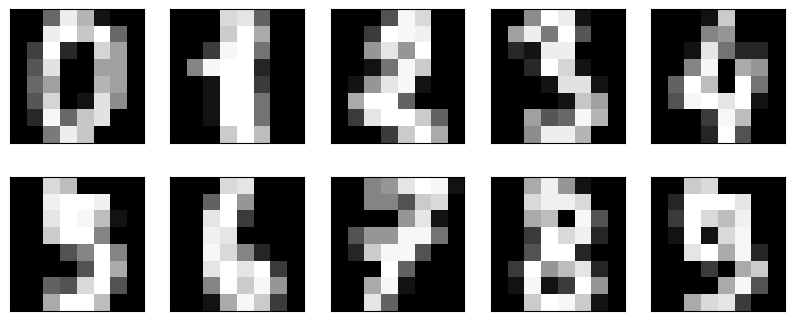

(1797, 64)


In [3]:
# 画像表示
n_img = 10
plt.figure(figsize=(10, 4))

for i in range(n_img):
    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(digits_data.data[i].reshape(8, 8), cmap="Greys_r")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

print(digits_data.data.shape)

## 訓練用とテスト用に分割

In [4]:
digit_images = digits_data.data
labels = digits_data.target

# 分割
x_train, x_test, t_train, t_test = train_test_split(digit_images, labels, test_size=0.2)

# Tensorに変換
x_train = torch.tensor(x_train, dtype=torch.float32)
t_train = torch.tensor(t_train, dtype=torch.int64)
x_test  = torch.tensor(x_test, dtype=torch.float32)
t_test  = torch.tensor(t_test, dtype=torch.int64)

## モデル構築

In [5]:
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 10)
)

In [6]:
model

Sequential(
  (0): Linear(in_features=64, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=10, bias=True)
)

## 学習

### ハイパーパラメータ

In [7]:
LR = 0.01
N_EPOCH = 1000

### 学習処理

In [8]:
%%time
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR)    # lr: 学習率

record_train_loss = []
record_test_loss = []

for i in tqdm(range(N_EPOCH)):
    # パラメータの勾配を0に
    optimizer.zero_grad()

    # 順伝搬
    y_train = model(x_train)
    y_test = model(x_test)

    # 誤差算出
    train_loss = loss_func(y_train, t_train)
    test_loss = loss_func(y_test, t_test)
    record_train_loss.append(train_loss.item())
    record_test_loss.append(test_loss.item())

    # 逆伝搬
    train_loss.backward()

    # パラメータ更新
    optimizer.step()

    if i % 100 == 0:
        print(f"Epoch: {i}, train_loss: {train_loss.item():.5f}, test_loss: {test_loss.item():.5f}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 0, train_loss: 2.56803, test_loss: 2.57962
Epoch: 100, train_loss: 1.88686, test_loss: 1.88513
Epoch: 200, train_loss: 1.04151, test_loss: 1.09799
Epoch: 300, train_loss: 0.48360, test_loss: 0.55619
Epoch: 400, train_loss: 0.30745, test_loss: 0.37388
Epoch: 500, train_loss: 0.22846, test_loss: 0.29190
Epoch: 600, train_loss: 0.18241, test_loss: 0.24736
Epoch: 700, train_loss: 0.15159, test_loss: 0.21931
Epoch: 800, train_loss: 0.12983, test_loss: 0.20054
Epoch: 900, train_loss: 0.11327, test_loss: 0.18725
CPU times: user 5.65 s, sys: 125 ms, total: 5.78 s
Wall time: 1.17 s


## 評価

### 誤差の推移

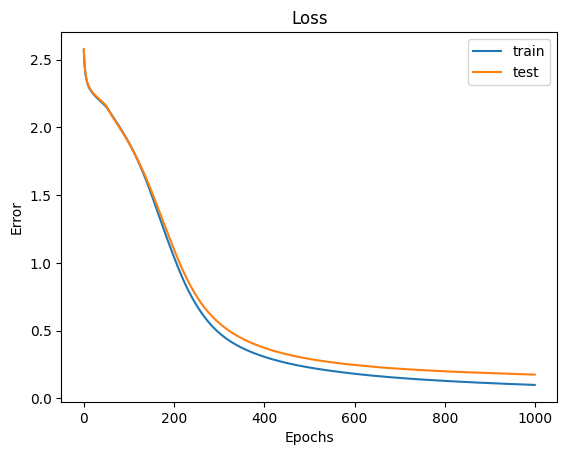

In [9]:
plt.plot(record_train_loss, label="train")
plt.plot(record_test_loss, label="test")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.show()

### 正答率算出

In [10]:
y_test = model(x_test)
count = (y_test.argmax(1) == t_test).sum().item()
print(f"Accuracy: {count / len(t_test)}")

Accuracy: 0.9472222222222222


### 訓練モデルを用いた予測

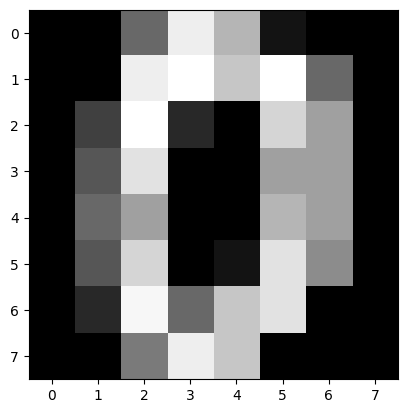

正解: 0, 予測: 0


In [11]:
img_id = 0
x_pred = digit_images[img_id]
image = x_pred.reshape(8, 8)
plt.imshow(image, cmap="Greys_r")
plt.show()

x_pred = torch.tensor(x_pred, dtype=torch.float32)
y_pred = model(x_pred)
print(f"正解: {labels[img_id]}, 予測: {y_pred.argmax().item()}")